
=== 处理数据集：10x-Multiome-Pbmc10k ===
✅ [10x-Multiome-Pbmc10k] - sheet[repeat_1] 读取成功
✅ [10x-Multiome-Pbmc10k] - sheet[repeat_2] 读取成功
✅ [10x-Multiome-Pbmc10k] - sheet[repeat_3] 读取成功
✅ [10x-Multiome-Pbmc10k] - sheet[repeat_4] 读取成功
✅ [10x-Multiome-Pbmc10k] - sheet[repeat_5] 读取成功

=== 处理数据集：D25 ===
✅ [D25] - sheet[repeat_1] 读取成功
✅ [D25] - sheet[repeat_2] 读取成功
✅ [D25] - sheet[repeat_3] 读取成功
✅ [D25] - sheet[repeat_4] 读取成功
✅ [D25] - sheet[repeat_5] 读取成功

=== 处理数据集：D31 ===
✅ [D31] - sheet[repeat_1] 读取成功
✅ [D31] - sheet[repeat_2] 读取成功
✅ [D31] - sheet[repeat_3] 读取成功
✅ [D31] - sheet[repeat_4] 读取成功
✅ [D31] - sheet[repeat_5] 读取成功

=== 处理数据集：Muto-2021 ===
✅ [Muto-2021] - sheet[repeat_1] 读取成功
✅ [Muto-2021] - sheet[repeat_2] 读取成功
✅ [Muto-2021] - sheet[repeat_3] 读取成功
✅ [Muto-2021] - sheet[repeat_4] 读取成功
✅ [Muto-2021] - sheet[repeat_5] 读取成功


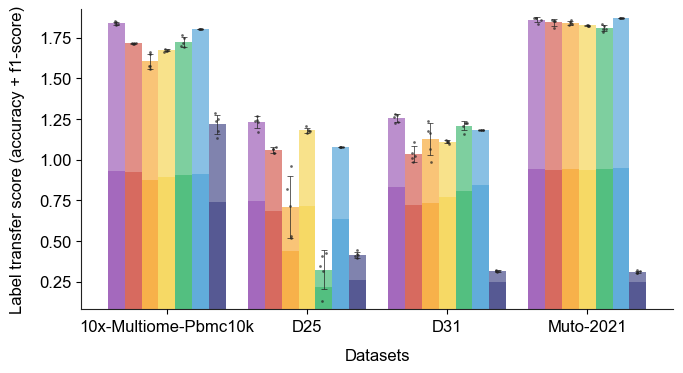


=== 各数据集-方法Label Transfer得分（均值±标准差） ===

【10x-Multiome-Pbmc10k】
- UniDISA: 1.8399 ± 0.0091
- MaxFuse: 1.7166 ± 0.0035
- scConfluence: 1.6064 ± 0.0424
- BindSC: 1.6726 ± 0.0056
- GLUE: 1.725 ± 0.0283
- Seurat: 1.8037 ± 0.0
- Uniport: 1.2171 ± 0.0544

【D25】
- UniDISA: 1.2313 ± 0.0332
- MaxFuse: 1.0588 ± 0.0167
- scConfluence: 0.7089 ± 0.1694
- BindSC: 1.1816 ± 0.0138
- GLUE: 0.3247 ± 0.1059
- Seurat: 1.0772 ± 0.0
- Uniport: 0.4162 ± 0.0158

【D31】
- UniDISA: 1.2564 ± 0.0232
- MaxFuse: 1.034 ± 0.0428
- scConfluence: 1.1277 ± 0.0899
- BindSC: 1.1106 ± 0.0076
- GLUE: 1.2102 ± 0.0268
- Seurat: 1.1837 ± 0.0
- Uniport: 0.3157 ± 0.0042

【Muto-2021】
- UniDISA: 1.8617 ± 0.0153
- MaxFuse: 1.846 ± 0.0185
- scConfluence: 1.8419 ± 0.0112
- BindSC: 1.8272 ± 0.0032
- GLUE: 1.812 ± 0.0157
- Seurat: 1.8752 ± 0.0
- Uniport: 0.3098 ± 0.0069


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import os

# =====================================================
# 1. 完全匹配参考代码的样式配置（字体/颜色/字号）
# =====================================================
# 字号配置（参考代码指定）
TINY_SIZE = 12
SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# 全局字体配置
plt.rc('font', size=TINY_SIZE)          # 全局默认字号
plt.rc('axes', titlesize=BIGGER_SIZE)   # 子图标题字号
plt.rc('axes', labelsize=MEDIUM_SIZE)   # x/y轴标签字号
plt.rc('xtick', labelsize=TINY_SIZE)    # x轴刻度字号
plt.rc('ytick', labelsize=TINY_SIZE)    # y轴刻度字号
plt.rc('legend', fontsize=MEDIUM_SIZE)  # 图例字号
plt.rc('figure', titlesize=BIGGER_SIZE) # 整体图标题字号

# Arial字体
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False  # 负号显示

# 参考代码的固定颜色（突出UniDISA）
fixed_color_palette = {
    'UniDISA':'#8E44AD' ,    # 紫色（突出）
    'MaxFuse': '#CD4537',    # 红色
    'scConfluence': '#F59E1D',# 橙色
    'BindSC': '#F4D03E',     # 黄色
    'GLUE': '#28AF60',       # 绿色
    'Seurat': '#3A97D2',     # 天蓝色
    'Uniport': '#2C3078'     # 深蓝色
}
METHOD_ORDER = ["UniDISA", "MaxFuse", "scConfluence", "BindSC", "GLUE", "Seurat", "Uniport"]
N_REPEAT = 5  # 5轮实验

# 指标配置（透明度区分Accuracy/F1_Score）
metric_config = {
    'Accuracy': {'alpha': 1.0, 'label': 'Accuracy'},  # 不透明
    'F1_Score': {'alpha': 0.6, 'label': 'F1_Score'}   # 半透明
}
metrics = ['Accuracy', 'F1_Score']


# =====================================================
# 2. 数据集配置（参考代码的本地路径）
# =====================================================
datasets = [
    {
        "name": "10x-Multiome-Pbmc10k",
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\10x-Multiome-Pbmc10k\label_transfer.xlsx"
    },
    {
        "name": "D25",
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D25\label_transfer.xlsx"
    },
    {
        "name": "D31",
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D31\label_transfer.xlsx"
    },
    {
        "name": "Muto-2021",
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\Muto-2021\label_transfer.xlsx"
    }
]

# 验证文件是否存在
for ds in datasets:
    if not os.path.exists(ds["file_path"]):
        print(f"⚠️  数据集[{ds['name']}]文件不存在：{ds['file_path']}")


# =====================================================
# 3. 数据读取（保留原始Repeat+均值）
# =====================================================
def process_label_transfer_dataset(file_path, dataset_name):
    """读取5个Repeat，返回：
    - df_mean：Accuracy/F1_Score均值（堆叠柱）
    - df_total_stats：总和均值/标准差（误差棒）
    - df_total_raw：总和原始值（散点）
    """
    all_repeats = []
    for repeat_idx in range(1, N_REPEAT + 1):
        sheet_name = f"repeat_{repeat_idx}"
        try:
            df = pd.read_excel(file_path, sheet_name=sheet_name)
            # 验证列
            required_cols = ["Method", "Accuracy", "F1_Score"]
            assert all(col in df.columns for col in required_cols), f"sheet[{sheet_name}]缺少列：{required_cols}"
            
            # 统一方法名+筛选
            df['Method'] = df['Method'].str.replace('bindSC', 'BindSC').str.strip()
            df = df[df['Method'].isin(METHOD_ORDER)].copy()
            
            # 计算总和
            df['Label_Transfer_Total'] = df['Accuracy'] + df['F1_Score']
            df['Dataset'] = dataset_name
            df['Repeat'] = repeat_idx
            
            all_repeats.append(df[['Dataset', 'Method', 'Repeat', 'Accuracy', 'F1_Score', 'Label_Transfer_Total']])
            print(f"✅ [{dataset_name}] - sheet[{sheet_name}] 读取成功")
        except Exception as e:
            print(f"❌ [{dataset_name}] - sheet[{sheet_name}] 失败：{str(e)}")
    
    if not all_repeats:
        return None, None, None
    
    df_all = pd.concat(all_repeats, ignore_index=True)
    # 指标均值（堆叠柱）
    df_mean = df_all.groupby(['Dataset', 'Method'])[metrics].mean().reset_index()
    # 总和统计（误差棒）
    df_total_stats = df_all.groupby(['Dataset', 'Method'])['Label_Transfer_Total'].agg(['mean', 'std']).reset_index()
    # 总和原始值（散点）
    df_total_raw = df_all[['Dataset', 'Method', 'Repeat', 'Label_Transfer_Total']]
    
    return df_mean, df_total_stats, df_total_raw


# 批量处理有效数据集
valid_mean = []
valid_total_stats = []
valid_total_raw = []
for ds in datasets:
    if os.path.exists(ds["file_path"]):
        print(f"\n=== 处理数据集：{ds['name']} ===")
        df_m, df_ts, df_tr = process_label_transfer_dataset(ds["file_path"], ds["name"])
        if df_m is not None:
            valid_mean.append(df_m)
            valid_total_stats.append(df_ts)
            valid_total_raw.append(df_tr)

if not valid_mean:
    raise ValueError("无有效数据集！请检查文件路径")

df_mean = pd.concat(valid_mean, ignore_index=True)
df_total_stats = pd.concat(valid_total_stats, ignore_index=True)
df_total_raw = pd.concat(valid_total_raw, ignore_index=True)
dataset_names = sorted(df_mean['Dataset'].unique())
n_datasets = len(dataset_names)
n_methods = len(METHOD_ORDER)


# =====================================================
# 4. 绘图（无任何网格线）
# =====================================================
bar_width = 0.12
x_base = np.arange(n_datasets)  

fig, ax = plt.subplots(figsize=(8, 4))

# ---------------------- 绘制堆叠柱 ----------------------
for method_idx, method in enumerate(METHOD_ORDER):
    method_mean = df_mean[df_mean['Method'] == method].copy()
    method_mean['Dataset'] = pd.Categorical(method_mean['Dataset'], categories=dataset_names, ordered=True)
    method_mean = method_mean.sort_values('Dataset').reset_index(drop=True)
    
    acc_scores = []
    f1_scores = []
    for ds in dataset_names:
        ds_row = method_mean[method_mean['Dataset'] == ds]
        if not ds_row.empty:
            acc_scores.append(ds_row['Accuracy'].iloc[0])
            f1_scores.append(ds_row['F1_Score'].iloc[0])
        else:
            acc_scores.append(0)
            f1_scores.append(0)
    
    x_pos = x_base + (method_idx - (n_methods - 1) / 2) * bar_width
    
    # 绘制Accuracy
    ax.bar(
        x_pos, acc_scores, bar_width,
        color=fixed_color_palette[method],
        alpha=0.8,
        edgecolor='none',
        linewidth=0
    )
    
    # 绘制F1_Score
    ax.bar(
        x_pos, f1_scores, bar_width, bottom=acc_scores,
        color=fixed_color_palette[method],
        alpha=0.6,
        edgecolor='none',
        linewidth=0
    )

# ---------------------- 绘制误差棒 ----------------------
for method_idx, method in enumerate(METHOD_ORDER):
    method_stats = df_total_stats[df_total_stats['Method'] == method].copy()
    method_stats['Dataset'] = pd.Categorical(method_stats['Dataset'], categories=dataset_names, ordered=True)
    method_stats = method_stats.sort_values('Dataset').reset_index(drop=True)
    
    total_means = []
    total_stds = []
    for ds in dataset_names:
        ds_row = method_stats[method_stats['Dataset'] == ds]
        if not ds_row.empty:
            total_means.append(ds_row['mean'].iloc[0])
            total_stds.append(ds_row['std'].iloc[0])
        else:
            total_means.append(0)
            total_stds.append(0)
    
    x_pos = x_base + (method_idx - (n_methods - 1) / 2) * bar_width
    ax.errorbar(
        x_pos, total_means, yerr=total_stds,
        fmt='none',
        color='#222222',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5
    )

# ---------------------- 绘制散点 ----------------------
for method_idx, method in enumerate(METHOD_ORDER):
    method_raw = df_total_raw[df_total_raw['Method'] == method].copy()
    x_pos_base = x_base + (method_idx - (n_methods - 1) / 2) * bar_width
    
    for ds_idx, ds in enumerate(dataset_names):
        ds_raw = method_raw[method_raw['Dataset'] == ds]['Label_Transfer_Total'].values
        if len(ds_raw) == 0:
            continue
        point_x = x_pos_base[ds_idx] + np.random.normal(0, 0.01, N_REPEAT)
        ax.scatter(
            point_x, ds_raw,
            color='#222222',
            s=15,
            alpha=0.7,
            marker='.',
            linewidth=0
        )

# =====================================================
# 5. 图表细节（彻底移除所有网格线）
# =====================================================
ax.set_xlabel("Datasets", fontsize=MEDIUM_SIZE, labelpad=10)
ax.set_ylabel("Label transfer score (accuracy + f1-score)", fontsize=MEDIUM_SIZE, labelpad=10)

ax.set_xticks(x_base)
ax.set_xticklabels(dataset_names, rotation=0)

# 纵坐标范围
all_total_values = df_total_raw['Label_Transfer_Total'].values
y_min = np.min(all_total_values) - 0.05 if len(all_total_values) > 0 else 0
y_max = np.max(all_total_values) + 0.05 if len(all_total_values) > 0 else 2
ax.set_ylim(y_min, y_max)

# 边框设置
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')

# ========== 核心：彻底关闭所有网格线 ==========
ax.grid(False)  # 关闭所有网格（水平+垂直）
ax.set_axisbelow(False)  # 无需将网格置于底层（因为无网格）


plt.subplots_adjust(left=0.08, right=0.82, top=0.9, bottom=0.15)

plt.savefig(
    "Fig2c.jpg",
    dpi=500,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)


# 显示图表
plt.show()

# =====================================================
# 数据摘要（匹配参考格式）
# =====================================================
print("\n=== 各数据集-方法Label Transfer得分（均值±标准差） ===")
for ds_name in dataset_names:
    print(f"\n【{ds_name}】")
    ds_data = df_total_raw[df_total_raw['Dataset'] == ds_name]
    for method in METHOD_ORDER:
        method_data = ds_data[ds_data["Method"] == method]["Label_Transfer_Total"]
        if len(method_data) == 0:
            print(f"- {method}: 无数据")
            continue
        mean = np.mean(method_data).round(4)
        std = np.std(method_data).round(4)
        print(f"- {method}: {mean} ± {std}")